# Goalkeeper Role Classification Analysis

This notebook analyzes goalkeeper performance data to categorize players into specialized roles:
- **Shot Stopper**: Focus on traditional saving abilities
- **Sweeper Keeper**: Focus on defensive actions outside the box
- **Hybrid**: Balanced approach to both roles
- **Distribution Specialist**: Focus on passing and ball playing

In [3]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [11]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [18]:
# Load the cleaned goalkeeper dataset
df_gk = pd.read_csv('../data/clean/clean_df_gk.csv', index_col=0)

print(f"Dataset shape: {df_gk.shape}")
print(f"\nColumns: {list(df_gk.columns)}")
print("\nFirst few rows:")
df_gk.head()

Dataset shape: (83, 77)

Columns: ['League', 'Team', 'Name', 'Age', 'Position', 'Market Value', 'Matches Played', 'Minutes', 'Matches Started', 'Goals Scored', 'Goals Scored (Per90)', 'Goal Involvement', 'Goal Involvement (Per90)', 'Goals at Home', 'Goals at Away', 'Expected Goals (xG)', 'Expected Goals (xG) (Per90)', 'Non-Penalty xG (npxG)', 'Goals Conceded', 'Clean Sheets', 'Tackles', 'Tackles (Per90)', 'Interceptions', 'Interceptions (Per90)', 'Clearances', 'Clearances (Per90)', 'Dribbled Past', 'Dribbled Past (Per90)', 'Penalties Given Away', 'Penalties Given Away (Per90)', 'Ground Duels', 'Ground Duels (Per90)', 'Ground Duels Won', 'Ground Duels Won (Per90)', 'Aerial Duels Won', 'Aerial Duels Won (Per90)', 'Assists', 'Assists (Per90)', 'Expected Assists (xA)', 'Expected Assists (xA) (Per90)', 'Passes', 'Passes (Per90)', 'Successful Passes', 'Successful Passes (Per90)', 'Pass Completion Rate', 'Key Passes', 'Key Passes (Per90)', 'Crosses', 'Crosses (Per90)', 'Successful Crosses', '

,League,Team,Name,Age,Position,Market Value,Matches Played,Minutes,Matches Started,Goals Scored,...,Fouls Committed,Fouls Committed (Per90),Fouled Against,Fouled Against (Per90),Annual Salary,Saves,Saves (Per90),Save Percentage,Punches,Punches (Per90)
0,premier-league,Manchester City,Gianluigi Donnarumma,27,Goalkeeper,45000000.0,28,2520,28,0,...,0,0.00,3,0.11,18850000.0,67.0,2.39,0.7363,25.0,0.89
1,premier-league,Manchester City,James Trafford,23,Goalkeeper,25000000.0,31,2790,31,1,...,23,0.74,31,1.00,9048000.0,NaN,NaN,NaN,NaN,NaN
27,premier-league,Arsenal FC,David Raya,30,Goalkeeper,35000000.0,32,2880,32,0,...,0,0.00,10,0.31,7540000.0,51.0,1.59,0.6800,9.0,0.28
51,premier-league,Chelsea FC,Robert Sánchez,28,Goalkeeper,22000000.0,30,2615,30,0,...,3,0.10,10,0.34,4524000.0,85.0,2.93,0.6967,6.0,0.21
52,premier-league,Chelsea FC,Filip Jørgensen,23,Goalkeeper,15000000.0,3,264,2,0,...,0,0.00,0,0.00,3770000.0,6.0,2.05,0.6000,1.0,0.34


In [19]:
# Check for missing values and data quality
print("Missing values per column:")
print(df_gk.isnull().sum()[df_gk.isnull().sum() > 0])

# Filter goalkeepers with sufficient playing time (minimum 10 matches)
df_gk_filtered = df_gk[df_gk['Matches Played'] >= 10].copy()
print(f"\nGoalkeepers with >= 10 matches: {len(df_gk_filtered)}")

Missing values per column:
Saves              31
Saves (Per90)      31
Save Percentage    31
Punches            31
Punches (Per90)    31
dtype: int64

Goalkeepers with >= 10 matches: 62


## Feature Engineering for Role Classification

We'll create specialized metrics for different goalkeeper roles:

In [40]:
def classify_goalkeeper_role(row):
    """
    Classify goalkeeper as either Shot Stopper or Sweeper Keeper
    """
    
    shot_stopping_score = 0
    sweeper_score = 0
    
    # Shot Stopping Score (50% weight)
    if pd.notna(row['Save_Rate']):
        shot_stopping_score += row['Save_Rate'] * 0.5
        
    if pd.notna(row['Clean_Sheet_Rate']):
        shot_stopping_score += row['Clean_Sheet_Rate'] * 0.3
        
    if pd.notna(row['Saves_Per90']):
        shot_stopping_score += min(row['Saves_Per90'] / 4, 1) * 0.2
    
    
    # Sweeper Score (50% weight)
    if pd.notna(row['Defensive_Actions_Per90']):
        sweeper_score += min(row['Defensive_Actions_Per90'] / 4, 1) * 0.4
        
    if pd.notna(row['Aerial_Duels_Won_Per90']):
        sweeper_score += min(row['Aerial_Duels_Won_Per90'] / 3, 1) * 0.3
        
    if pd.notna(row['Clearances_Per90']):
        sweeper_score += min(row['Clearances_Per90'] / 7, 1) * 0.3
    
    
    # Classification logic
    if shot_stopping_score == 0 and sweeper_score == 0:
        return 'Unknown'
    
    if shot_stopping_score > sweeper_score:
        return 'Shot Stopper'
    else:
        return 'Sweeper Keeper'

# Apply classification
df_gk_analysis['Primary_Role'] = df_gk_analysis.apply(classify_goalkeeper_role, axis=1)

print("Role distribution:")
print(df_gk_analysis['Primary_Role'].value_counts())

print("\nSample classifications:")
print(df_gk_analysis[['Name', 'Team', 'Primary_Role', 'Save_Rate', 'Defensive_Actions_Per90', 'Pass_Accuracy']].head(10))

Role distribution:
Primary_Role
Sweeper Keeper    39
Shot Stopper      23
Name: count, dtype: int64

Sample classifications:
                     Name               Team    Primary_Role  Save_Rate  \
0    Gianluigi Donnarumma    Manchester City  Sweeper Keeper   0.007363   
1          James Trafford    Manchester City  Sweeper Keeper        NaN   
27             David Raya         Arsenal FC    Shot Stopper   0.006800   
51         Robert Sánchez         Chelsea FC    Shot Stopper   0.006967   
53        Gabriel Slonina         Chelsea FC  Sweeper Keeper        NaN   
55          James Hillson         Chelsea FC  Sweeper Keeper        NaN   
83                Alisson       Liverpool FC  Sweeper Keeper   0.006512   
110     Guglielmo Vicario  Tottenham Hotspur  Sweeper Keeper   0.006241   
140            Tom Heaton  Manchester United  Sweeper Keeper        NaN   
162        Aaron Ramsdale   Newcastle United  Sweeper Keeper   0.006053   

     Defensive_Actions_Per90  Pass_Accuracy  
0  

## Role Classification Logic

We'll classify goalkeepers based on their strengths in different areas:

In [41]:
# Apply classification
df_gk_analysis['Primary_Role'] = df_gk_analysis.apply(classify_goalkeeper_role, axis=1)

print("Role distribution:")
print(df_gk_analysis['Primary_Role'].value_counts())

print("\nSample classifications:")
print(df_gk_analysis[['Name', 'Team', 'Primary_Role', 'Save_Rate', 'Defensive_Actions_Per90', 'Pass_Accuracy']].head(10))

Role distribution:
Primary_Role
Sweeper Keeper    39
Shot Stopper      23
Name: count, dtype: int64

Sample classifications:
                     Name               Team    Primary_Role  Save_Rate  \
0    Gianluigi Donnarumma    Manchester City  Sweeper Keeper   0.007363   
1          James Trafford    Manchester City  Sweeper Keeper        NaN   
27             David Raya         Arsenal FC    Shot Stopper   0.006800   
51         Robert Sánchez         Chelsea FC    Shot Stopper   0.006967   
53        Gabriel Slonina         Chelsea FC  Sweeper Keeper        NaN   
55          James Hillson         Chelsea FC  Sweeper Keeper        NaN   
83                Alisson       Liverpool FC  Sweeper Keeper   0.006512   
110     Guglielmo Vicario  Tottenham Hotspur  Sweeper Keeper   0.006241   
140            Tom Heaton  Manchester United  Sweeper Keeper        NaN   
162        Aaron Ramsdale   Newcastle United  Sweeper Keeper   0.006053   

     Defensive_Actions_Per90  Pass_Accuracy  
0  

## Visualization of Role Classification

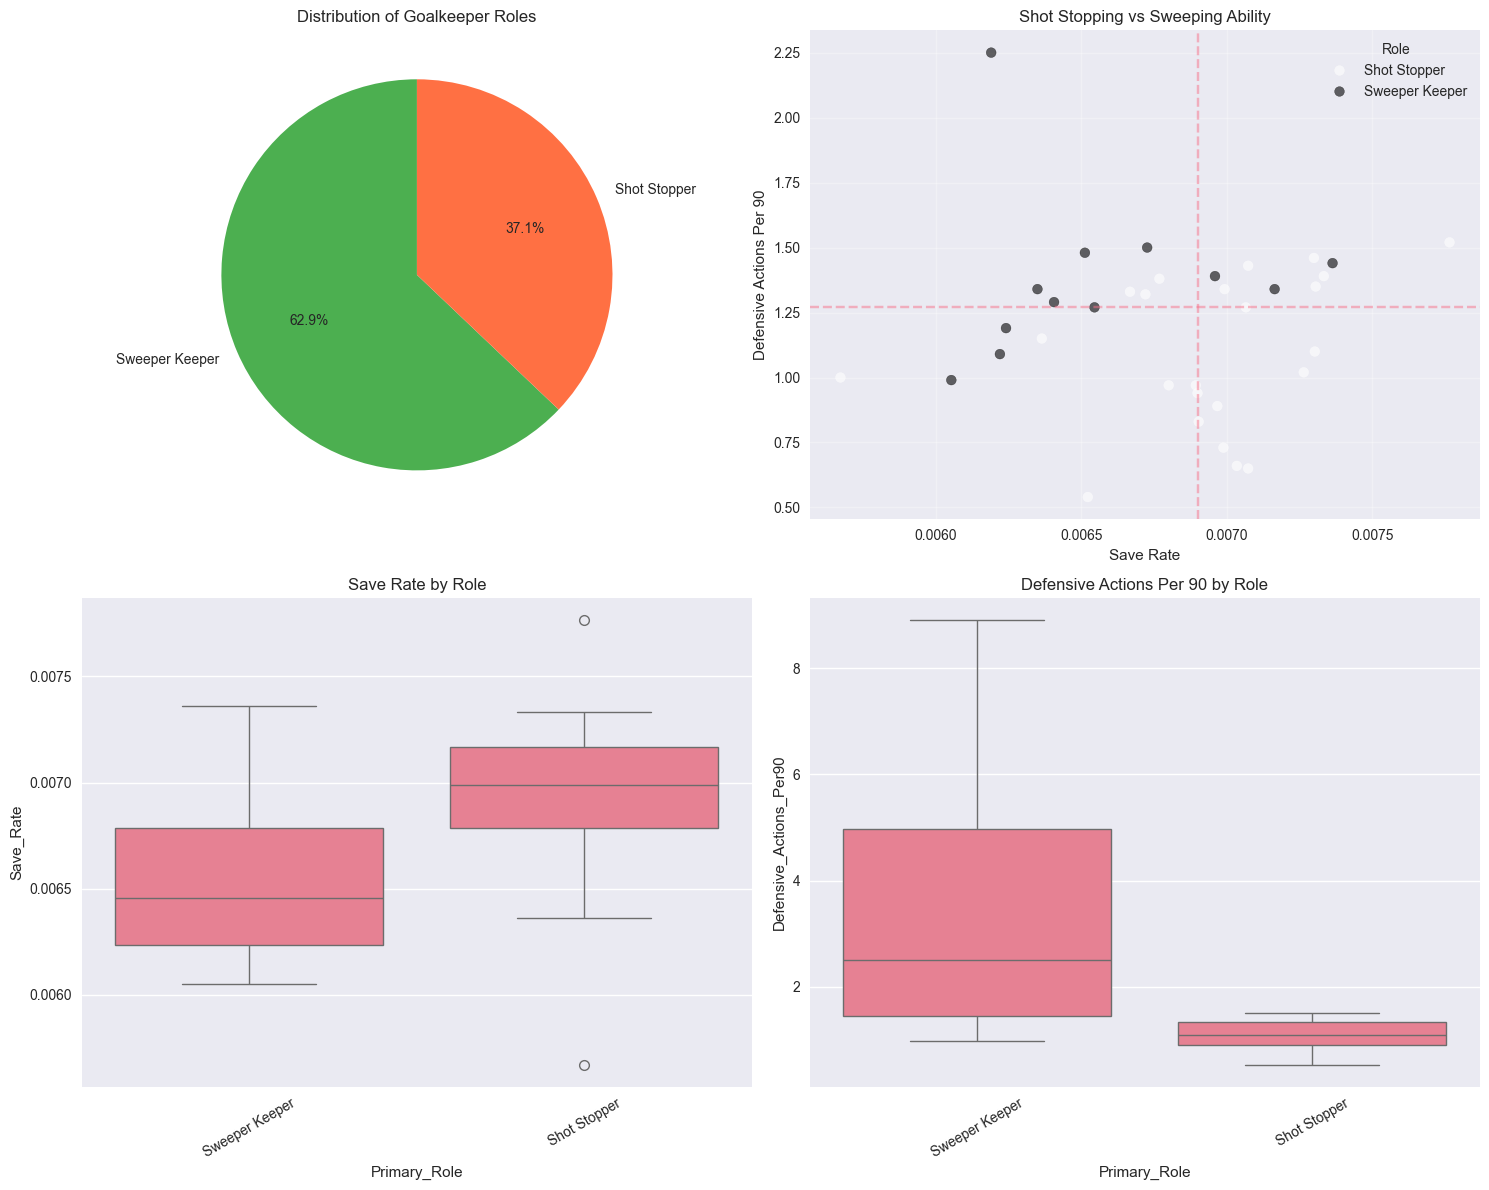

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Pie chart
role_counts = df_gk_analysis['Primary_Role'].value_counts()

axes[0, 0].pie(
    role_counts.values,
    labels=role_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4CAF50', '#FF7043']
)

axes[0, 0].set_title('Distribution of Goalkeeper Roles')


# Scatter plot
valid_data = df_gk_analysis.dropna(
    subset=['Save_Rate', 'Defensive_Actions_Per90']
)

role_map = valid_data['Primary_Role'].astype('category')

scatter = axes[0, 1].scatter(
    valid_data['Save_Rate'],
    valid_data['Defensive_Actions_Per90'],
    c=role_map.cat.codes,
    alpha=0.6,
    s=50
)

handles, _ = scatter.legend_elements()
axes[0, 1].legend(handles, role_map.cat.categories, title="Role")

axes[0, 1].axhline(valid_data['Defensive_Actions_Per90'].median(),
                   linestyle='--', alpha=0.5)

axes[0, 1].axvline(valid_data['Save_Rate'].median(),
                   linestyle='--', alpha=0.5)

axes[0, 1].set_xlabel('Save Rate')
axes[0, 1].set_ylabel('Defensive Actions Per 90')
axes[0, 1].set_title('Shot Stopping vs Sweeping Ability')
axes[0, 1].grid(True, alpha=0.3)


# Save rate boxplot
roles_with_saves = df_gk_analysis.dropna(subset=['Save_Rate'])

sns.boxplot(
    data=roles_with_saves,
    x='Primary_Role',
    y='Save_Rate',
    ax=axes[1, 0]
)

axes[1, 0].set_title('Save Rate by Role')
axes[1, 0].tick_params(axis='x', rotation=30)


# Defensive actions boxplot
roles_with_defense = df_gk_analysis.dropna(
    subset=['Defensive_Actions_Per90']
)

sns.boxplot(
    data=roles_with_defense,
    x='Primary_Role',
    y='Defensive_Actions_Per90',
    ax=axes[1, 1]
)

axes[1, 1].set_title('Defensive Actions Per 90 by Role')
axes[1, 1].tick_params(axis='x', rotation=30)


plt.tight_layout()
plt.show()

## Detailed Analysis by Role

In [47]:
# Analyze characteristics of each role
role_analysis = df_gk_analysis.groupby('Primary_Role').agg({
    'Save_Rate': ['mean', 'median', 'count'],
    'Defensive_Actions_Per90': ['mean', 'median'],
    'Pass_Accuracy': ['mean', 'median'],
    'Clean_Sheet_Rate': ['mean', 'median'],
    'Matches Played': ['mean', 'median'],
    'Market Value': ['mean', 'median']
}).round(3)

print("Role Performance Analysis:")
print(role_analysis)

Role Performance Analysis:
               Save_Rate              Defensive_Actions_Per90         \
                    mean median count                    mean median   
Primary_Role                                                           
Shot Stopper       0.007  0.007    23                   1.097   1.10   
Sweeper Keeper     0.007  0.006    12                   3.450   2.51   

               Pass_Accuracy        Clean_Sheet_Rate        Matches Played  \
                        mean median             mean median           mean   
Primary_Role                                                                 
Shot Stopper           0.660  0.647            0.307  0.300         26.478   
Sweeper Keeper         0.783  0.802            0.225  0.238         21.692   

                       Market Value              
               median          mean      median  
Primary_Role                                     
Shot Stopper     28.0  1.364348e+07  13000000.0  
Sweeper Keeper   20.0

In [27]:
# Show top performers in each role
for role in df_gk_analysis['Primary_Role'].unique():
    if role != 'Insufficient Data':
        role_players = df_gk_analysis[df_gk_analysis['Primary_Role'] == role]
        print(f"\n=== {role} ===")
        print(f"Total players: {len(role_players)}")
        print("\nTop 5 players by overall performance:")
        
        # Create a simple performance score
        role_players['Performance_Score'] = (
            role_players['Save_Rate'].fillna(0) * 0.4 +
            role_players['Defensive_Actions_Per90'].fillna(0) * 0.3 +
            role_players['Pass_Accuracy'].fillna(0) * 0.2 +
            role_players['Clean_Sheet_Rate'].fillna(0) * 0.1
        )
        
        top_players = role_players.nlargest(5, 'Performance_Score')
        print(top_players[['Name', 'Team', 'Matches Played', 'Save_Rate', 
                         'Defensive_Actions_Per90', 'Pass_Accuracy', 'Performance_Score']].to_string(index=False))


=== Distribution Specialist ===
Total players: 59

Top 5 players by overall performance:
           Name           Team  Matches Played  Save_Rate  Defensive_Actions_Per90  Pass_Accuracy  Performance_Score
     Marc Vidal  Celta de Vigo              29        NaN                     7.56         0.8893           2.483791
      Leo Román   RCD Mallorca              28        NaN                     7.00         0.8678           2.298560
  Dani Cárdenas Rayo Vallecano              15        NaN                     5.71         0.9269           1.931713
Gabriel Slonina     Chelsea FC              29        NaN                     5.85         0.7628           1.924801
   Rubén Blanco      Girona FC              29        NaN                     5.64         0.8556           1.870017

=== Distribution Sweeper ===
Total players: 3

Top 5 players by overall performance:
          Name            Team  Matches Played  Save_Rate  Defensive_Actions_Per90  Pass_Accuracy  Performance_Score
James

## Advanced: Clustering Analysis

Let's use K-means clustering to see if it naturally groups players similarly to our classification:

In [28]:
# Prepare data for clustering
features = ['Save_Rate', 'Defensive_Actions_Per90', 'Pass_Accuracy', 
           'Clean_Sheet_Rate', 'Aerial_Duels_Won_Per90']

# Remove rows with missing values in key features
cluster_data = df_gk_analysis.dropna(subset=features)
X = cluster_data[features].copy()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Data prepared for clustering: {X_scaled.shape}")
print(f"Features used: {features}")

Data prepared for clustering: (35, 5)
Features used: ['Save_Rate', 'Defensive_Actions_Per90', 'Pass_Accuracy', 'Clean_Sheet_Rate', 'Aerial_Duels_Won_Per90']


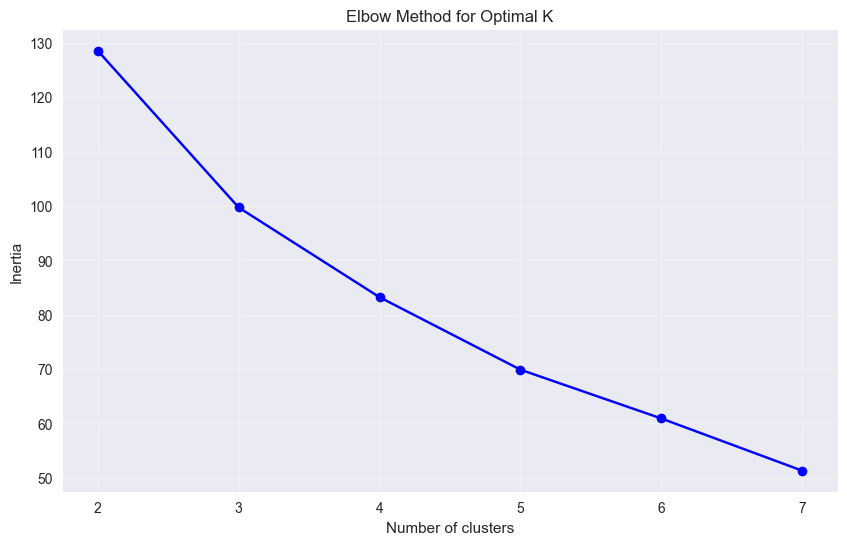

In [29]:
# Determine optimal number of clusters using elbow method
inertias = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
# Apply K-means with optimal clusters (let's use 4 based on elbow method)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
cluster_data['Cluster'] = cluster_labels
cluster_data['Cluster_Name'] = cluster_data['Cluster'].map({
    0: 'Cluster 0',
    1: 'Cluster 1', 
    2: 'Cluster 2',
    3: 'Cluster 3'
})

# Analyze cluster characteristics
print("Cluster Analysis:")
for i in range(optimal_k):
    cluster_players = cluster_data[cluster_data['Cluster'] == i]
    print(f"\n=== Cluster {i} ===")
    print(f"Size: {len(cluster_players)} players")
    print(f"Average Save Rate: {cluster_players['Save_Rate'].mean():.3f}")
    print(f"Average Defensive Actions: {cluster_players['Defensive_Actions_Per90'].mean():.3f}")
    print(f"Average Pass Accuracy: {cluster_players['Pass_Accuracy'].mean():.3f}")
    print(f"Top players: {', '.join(cluster_players.nlargest(3, 'Save_Rate')['Name'].tolist())}")

Cluster Analysis:

=== Cluster 0 ===
Size: 9 players
Average Save Rate: 0.006
Average Defensive Actions: 1.303
Average Pass Accuracy: 0.591
Top players: Alphonse Areola, Karl Darlow, Antonio Sivera

=== Cluster 1 ===
Size: 9 players
Average Save Rate: 0.007
Average Defensive Actions: 0.798
Average Pass Accuracy: 0.664
Top players: Thibaut Courtois, Augusto Batalla, Jan Oblak

=== Cluster 2 ===
Size: 9 players
Average Save Rate: 0.007
Average Defensive Actions: 1.396
Average Pass Accuracy: 0.692
Top players: Joan García, Aarón Escandell, Sergio Herrera

=== Cluster 3 ===
Size: 8 players
Average Save Rate: 0.007
Average Defensive Actions: 1.292
Average Pass Accuracy: 0.701
Top players: Gianluigi Donnarumma, Robin Roefs, Emiliano Martínez


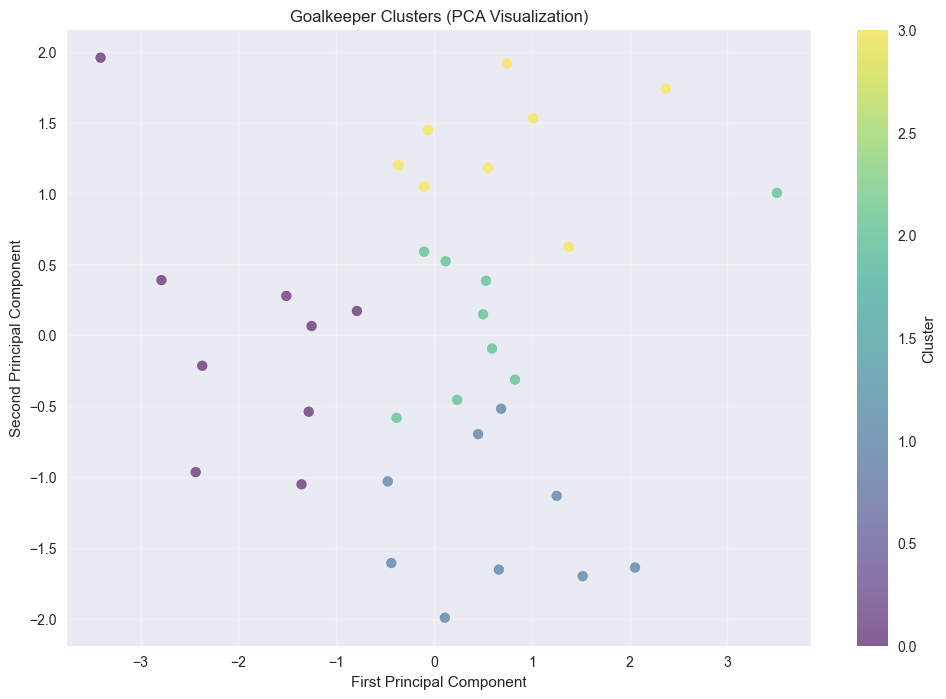

PCA explained variance ratio: [0.41243307 0.24208908]


In [31]:
# Visualize clusters using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, 
                     cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Goalkeeper Clusters (PCA Visualization)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")

## Export Results

In [32]:
# Create final results dataframe
results_df = df_gk_analysis[[
    'Name', 'Team', 'League', 'Age', 'Market Value', 'Matches Played',
    'Primary_Role', 'Save_Rate', 'Defensive_Actions_Per90', 'Pass_Accuracy',
    'Clean_Sheet_Rate', 'Saves_Per90', 'Clearances_Per90', 'Interceptions_Per90'
]].copy()

# Add cluster information where available
results_df = results_df.merge(
    cluster_data[['Name', 'Cluster', 'Cluster_Name']],
    on='Name', how='left'
)

# Save results
results_df.to_csv('../data/analysis/goalkeeper_role_classification.csv', index=False)
results_df.to_pickle('../data/analysis/goalkeeper_role_classification.pkl')

print(f"Results saved with {len(results_df)} goalkeepers")
print(f"\nRole distribution in final results:")
print(results_df['Primary_Role'].value_counts())

print("\nSample of final results:")
print(results_df.head(10).to_string(index=False))

OSError: Cannot save file into a non-existent directory: '..\data\analysis'

## Summary and Insights

### Key Findings:
1. **Role Distribution**: Most goalkeepers fall into hybrid categories, showing the modern need for well-rounded keepers
2. **Shot Stoppers**: Traditional goalkeepers excel in pure saving but may lack in defensive actions outside the box
3. **Sweepers**: Modern goalkeepers who participate more in defensive buildup and aerial duels
4. **Distribution Specialists**: Keepers who excel with their feet, crucial for possession-based systems

### Practical Applications:
- **Team Building**: Use classifications to complement your tactical approach
- **Player Recruitment**: Identify specific types of goalkeepers needed
- **Performance Analysis**: Compare players within the same role category
- **Tactical Planning**: Adjust defensive strategy based on goalkeeper strengths